Portfolio Optimization Project







Phase 1- Import Required Libraries

In [1]:
# Importing the pandas library, which is used for data manipulation and analysis.
import pandas as pd
import numpy as np

# Download financial data
import yfinance as yf

# Data visualization
import matplotlib.pyplot as plt

# Statistical visualization
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
tickers =["SPY", "QQQ", "VTI", "IWM", "EFA", "EEM", "VNQ", "GLD", "TLT", "HYG"]
data = yf.download (
    tickers,
    start="2018-01-01",
    end="2026-01-01"
)

[*********************100%***********************]  10 of 10 completed


In [3]:
data.head()

Price           Close                                                \
Ticker            EEM        EFA         GLD        HYG         IWM   
Date                                                                  
2018-01-02  39.776550  54.737137  125.150002  55.549301  138.554916   
2018-01-03  40.157665  54.999886  124.820000  55.816399  138.698944   
2018-01-04  40.356514  55.602661  125.459999  55.911819  139.068054   
2018-01-05  40.704487  55.911774  125.330002  55.949989  139.356125   
2018-01-08  40.704487  55.896320  125.309998  55.905453  139.572205   

Price                                                                 ...  \
Ticker             QQQ         SPY        TLT        VNQ         VTI  ...   
Date                                                                  ...   
2018-01-02  150.057251  235.954300  98.342461  59.645275  121.111961  ...   
2018-01-03  151.515305  237.446732  98.812614  59.472111  121.812988  ...   
2018-01-04  151.780411  238.447571  98.796982  58.447590  122.277359  ...   
2018-01-05  153.304764  240.036560  98.514908  58.476486  122.995842  ...   
2018-01-08  153.901230  240.475479  98.452156  58.779484  123.276230  ...   

Price         Volume                                                    \
Ticker           EEM       EFA       GLD       HYG       IWM       QQQ   
Date                                                                     
2018-01-02  68969400  26530000  11762500   7223500  20489600  32573300   
2018-01-03  56228700  33384900   7904300  20557100  21836600  29383600   
2018-01-04  52154900  23974400   7329700  13610900  14207100  24776100   
2018-01-05  50026900  17483800   5739900   9851600  19883900  26992300   
2018-01-08  36998200  21733700   3566700   9804000  18457300  23159100   

Price                                             
Ticker           SPY       TLT      VNQ      VTI  
Date                                              
2018-01-02  86655700  16238200  4639500  3699700  
2018-01-03  90070400   8605100  5516900  3052300  
2018-01-04  80636400   9217900  4734100  2572400  
2018-01-05  83524000  10915400  5742900  2188500  
2018-01-08  57319200   8850600  4763200  2655300  

[5 rows x 50 columns]

In [4]:
data.tail()

Price           Close                                                \
Ticker            EEM        EFA         GLD        HYG         IWM   
Date                                                                  
2025-12-24  54.138599  94.908134  411.929993  78.286545  251.662796   
2025-12-26  54.516636  95.065636  416.739990  78.247719  250.378143   
2025-12-29  54.377361  94.780151  398.600006  78.276833  248.844528   
2025-12-30  54.596222  94.937660  398.890015  78.354500  247.002182   
2025-12-31  54.427101  94.534042  396.309998  78.276833  245.139938   

Price                                                                 ...  \
Ticker             QQQ         SPY        TLT        VNQ         VTI  ...   
Date                                                                  ...   
2025-12-24  622.460266  686.730530  86.078072  87.053909  337.846680  ...   
2025-12-26  622.420288  686.660889  85.794502  87.151978  337.637939  ...   
2025-12-29  619.407410  684.213867  86.117180  87.328522  336.365601  ...   
2025-12-30  617.970764  683.378357  85.911835  87.505058  335.828796  ...   
2025-12-31  612.862854  678.315247  85.227348  86.789093  333.264252  ...   

Price         Volume                                                    \
Ticker           EEM       EFA       GLD       HYG       IWM       QQQ   
Date                                                                     
2025-12-24   9565300   5609700   6718400  10533500  12103000  18468700   
2025-12-26  11352000   9304200  10476200  10922900  17429900  28959800   
2025-12-29  18816700  16705400  20679200  22012700  25218800  32458300   
2025-12-30  24643000  15877000  10179000  20146700  22123600  31226800   
2025-12-31  20000900  27618000  10194700  17457100  35352000  40746500   

Price                                             
Ticker           SPY       TLT      VNQ      VTI  
Date                                              
2025-12-24  39445600  25942000  2730800  4006500  
2025-12-26  41613300  26522700  2065600  3543600  
2025-12-29  62559500  29399800  2604000  3795900  
2025-12-30  47160700  25106800  2813400  3576200  
2025-12-31  74144800  36500000  3301700  3493700  

[5 rows x 50 columns]

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2018-01-02 to 2025-12-31
Data columns (total 50 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, EEM)   2011 non-null   float64
 1   (Close, EFA)   2011 non-null   float64
 2   (Close, GLD)   2011 non-null   float64
 3   (Close, HYG)   2011 non-null   float64
 4   (Close, IWM)   2011 non-null   float64
 5   (Close, QQQ)   2011 non-null   float64
 6   (Close, SPY)   2011 non-null   float64
 7   (Close, TLT)   2011 non-null   float64
 8   (Close, VNQ)   2011 non-null   float64
 9   (Close, VTI)   2011 non-null   float64
 10  (High, EEM)    2011 non-null   float64
 11  (High, EFA)    2011 non-null   float64
 12  (High, GLD)    2011 non-null   float64
 13  (High, HYG)    2011 non-null   float64
 14  (High, IWM)    2011 non-null   float64
 15  (High, QQQ)    2011 non-null   float64
 16  (High, SPY)    2011 non-null   float64
 17  (High, TLT)    2011 non-null   flo

In [6]:
data.describe()

Price         Close                                                      \
Ticker          EEM          EFA          GLD          HYG          IWM   
count   2011.000000  2011.000000  2011.000000  2011.000000  2011.000000   
mean      39.837565    63.266385   184.155236    63.705740   176.852855   
std        5.313732    11.419298    60.867595     6.120835    33.505883   
min       26.664921    38.268452   111.099998    48.832806    92.240334   
25%       36.039749    53.759752   144.144997    59.426149   145.226212   
50%       38.490250    62.619282   170.630005    62.303371   177.188461   
75%       43.352825    69.314487   188.125000    66.931423   205.254410   
max       54.934235    95.065636   416.739990    78.354500   255.873627   

Price                                                                    ...  \
Ticker          QQQ          SPY          TLT          VNQ          VTI  ...   
count   2011.000000  2011.000000  2011.000000  2011.000000  2011.000000  ...   
mean     321.444177   391.998604   101.788846    74.328432   196.807143  ...   
std      128.221140   123.992626    17.864039    10.935174    59.535685  ...   
min      137.012802   204.418259    73.702690    44.828857   101.854736  ...   
25%      195.031105   271.769958    86.545300    65.978855   138.266441  ...   
50%      308.849243   385.423950    95.369003    73.692963   193.962372  ...   
75%      401.643219   459.318848   116.837784    85.153175   228.697189  ...   
max      633.456177   686.730530   142.699554    97.226738   337.846680  ...   

Price         Volume                                                          \
Ticker           EEM           EFA           GLD           HYG           IWM   
count   2.011000e+03  2.011000e+03  2.011000e+03  2.011000e+03  2.011000e+03   
mean    4.605054e+07  2.254155e+07  8.903189e+06  3.092270e+07  2.884498e+07   
std     2.603256e+07  1.282687e+07  5.091331e+06  1.664975e+07  1.265930e+07   
min     7.066800e+06  5.177900e+06  1.436500e+06  4.854900e+06  1.200000e+03   
25%     2.759055e+07  1.417570e+07  5.673600e+06  1.914130e+07  2.018035e+07   
50%     3.891500e+07  1.938540e+07  7.640500e+06  2.878770e+07  2.590920e+07   
75%     5.724650e+07  2.692980e+07  1.058125e+07  3.851585e+07  3.446585e+07   
max     2.040462e+08  1.223420e+08  6.202500e+07  1.933748e+08  1.230151e+08   

Price                                                                         
Ticker           QQQ           SPY           TLT           VNQ           VTI  
count   2.011000e+03  2.011000e+03  2.011000e+03  2.011000e+03  2.011000e+03  
mean    4.672163e+07  8.099087e+07  2.169471e+07  5.056486e+06  3.618554e+06  
std     2.206206e+07  4.044683e+07  1.581821e+07  2.328858e+06  2.004744e+06  
min     7.089000e+06  2.027000e+07  3.027900e+06  1.524100e+06  9.102000e+05  
25%     3.077155e+07  5.685475e+07  9.685300e+06  3.485600e+06  2.508950e+06  
50%     4.242610e+07  7.223880e+07  1.714730e+07  4.548700e+06  3.164200e+06  
75%     5.682020e+07  9.293705e+07  2.903740e+07  5.949350e+06  4.101800e+06  
max     1.986858e+08  3.922207e+08  1.313535e+08  2.247180e+07  2.227240e+07  

[8 rows x 50 columns]

In [7]:
data.isnull().sum()

Price   Ticker
Close   EEM       0
        EFA       0
        GLD       0
        HYG       0
        IWM       0
        QQQ       0
        SPY       0
        TLT       0
        VNQ       0
        VTI       0
High    EEM       0
        EFA       0
        GLD       0
        HYG       0
        IWM       0
        QQQ       0
        SPY       0
        TLT       0
        VNQ       0
        VTI       0
Low     EEM       0
        EFA       0
        GLD       0
        HYG       0
        IWM       0
        QQQ       0
        SPY       0
        TLT       0
        VNQ       0
        VTI       0
Open    EEM       0
        EFA       0
        GLD       0
        HYG       0
        IWM       0
        QQQ       0
        SPY       0
        TLT       0
        VNQ       0
        VTI       0
Volume  EEM       0
        EFA       0
        GLD       0
        HYG       0
        IWM       0
        QQQ       0
        SPY       0
        TLT       0
        VNQ       0
        VTI       0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.to_csv("raw_etf_data.csv")

Phase 2 - Data Cleaning

In [10]:
data = pd.read_csv("raw_etf_data.csv",
                   header=[0, 1],
                   index_col=0,
                   parse_dates=True
                   )

In [11]:
prices = data["Close"].copy()

In [12]:
prices.head()

Ticker,EEM,EFA,GLD,HYG,IWM,QQQ,SPY,TLT,VNQ,VTI
Date,,,,,,,,,,
2018-01-02,39.776550,54.737137,125.150002,55.549301,138.554916,150.057251,235.954300,98.342461,59.645275,121.111961
2018-01-03,40.157665,54.999886,124.820000,55.816399,138.698944,151.515305,237.446732,98.812614,59.472111,121.812988
2018-01-04,40.356514,55.602661,125.459999,55.911819,139.068054,151.780411,238.447571,98.796982,58.447590,122.277359
2018-01-05,40.704487,55.911774,125.330002,55.949989,139.356125,153.304764,240.036560,98.514908,58.476486,122.995842
2018-01-08,40.704487,55.896320,125.309998,55.905453,139.572205,153.901230,240.475479,98.452156,58.779484,123.276230


In [13]:
prices.tail()

Ticker,EEM,EFA,GLD,HYG,IWM,QQQ,SPY,TLT,VNQ,VTI
Date,,,,,,,,,,
2025-12-24,54.138599,94.908134,411.929993,78.286545,251.662796,622.460266,686.730530,86.078072,87.053909,337.846680
2025-12-26,54.516636,95.065636,416.739990,78.247719,250.378143,622.420288,686.660889,85.794502,87.151978,337.637939
2025-12-29,54.377361,94.780151,398.600006,78.276833,248.844528,619.407410,684.213867,86.117180,87.328522,336.365601
2025-12-30,54.596222,94.937660,398.890015,78.354500,247.002182,617.970764,683.378357,85.911835,87.505058,335.828796
2025-12-31,54.427101,94.534042,396.309998,78.276833,245.139938,612.862854,678.315247,85.227348,86.789093,333.264252


In [14]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2018-01-02 to 2025-12-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EEM     2011 non-null   float64
 1   EFA     2011 non-null   float64
 2   GLD     2011 non-null   float64
 3   HYG     2011 non-null   float64
 4   IWM     2011 non-null   float64
 5   QQQ     2011 non-null   float64
 6   SPY     2011 non-null   float64
 7   TLT     2011 non-null   float64
 8   VNQ     2011 non-null   float64
 9   VTI     2011 non-null   float64
dtypes: float64(10)
memory usage: 172.8 KB


In [15]:
prices.isnull().sum()

,0
Ticker,
EEM,0
EFA,0
GLD,0
HYG,0
IWM,0
QQQ,0
SPY,0
TLT,0
VNQ,0


In [16]:
prices.duplicated().sum()

np.int64(0)

In [17]:
prices.index.is_monotonic_increasing #Are my dates increasing and index is the Date column

True

In [18]:
prices.index.duplicated().sum()

np.int64(0)

In [19]:
prices.index.name = "Date"

In [20]:
prices.to_csv("cleaned_closing_prices.csv")

In [21]:
returns = prices.pct_change().dropna() #Drops NAN in the first row

In [22]:
returns.head()

Ticker,EEM,EFA,GLD,HYG,IWM,QQQ,SPY,TLT,VNQ,VTI
Date,,,,,,,,,,
2018-01-03,0.009581,0.004800,-0.002637,0.004808,0.001039,0.009717,0.006325,0.004781,-0.002903,0.005788
2018-01-04,0.004952,0.010960,0.005127,0.001710,0.002661,0.001750,0.004215,-0.000158,-0.017227,0.003812
2018-01-05,0.008622,0.005559,-0.001036,0.000683,0.002071,0.010043,0.006664,-0.002855,0.000494,0.005876
2018-01-08,0.000000,-0.000276,-0.000160,-0.000796,0.001551,0.003891,0.001829,-0.000637,0.005182,0.002280
2018-01-09,-0.001629,0.001106,-0.004628,-0.003072,-0.001354,0.000062,0.002263,-0.013373,-0.012888,0.001848


In [23]:
returns.tail()

Ticker,EEM,EFA,GLD,HYG,IWM,QQQ,SPY,TLT,VNQ,VTI
Date,,,,,,,,,,
2025-12-24,0.002025,0.001246,-0.004134,0.001864,0.002499,0.002926,0.003518,0.006057,0.006577,0.003425
2025-12-26,0.006983,0.001660,0.011677,-0.000496,-0.005105,-0.000064,-0.000101,-0.003294,0.001127,-0.000618
2025-12-29,-0.002555,-0.003003,-0.043528,0.000372,-0.006125,-0.004841,-0.003564,0.003761,0.002026,-0.003768
2025-12-30,0.004025,0.001662,0.000728,0.000992,-0.007404,-0.002319,-0.001221,-0.002384,0.002022,-0.001596
2025-12-31,-0.003098,-0.004251,-0.006468,-0.000991,-0.007539,-0.008266,-0.007409,-0.007967,-0.008182,-0.007636


In [24]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2010 entries, 2018-01-03 to 2025-12-31
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EEM     2010 non-null   float64
 1   EFA     2010 non-null   float64
 2   GLD     2010 non-null   float64
 3   HYG     2010 non-null   float64
 4   IWM     2010 non-null   float64
 5   QQQ     2010 non-null   float64
 6   SPY     2010 non-null   float64
 7   TLT     2010 non-null   float64
 8   VNQ     2010 non-null   float64
 9   VTI     2010 non-null   float64
dtypes: float64(10)
memory usage: 172.7 KB


In [25]:
returns.describe()

Ticker,EEM,EFA,GLD,HYG,IWM,QQQ,SPY,TLT,VNQ,VTI
count,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000
mean,0.000243,0.000336,0.000619,0.000186,0.000405,0.000815,0.000601,-0.000022,0.000286,0.000582
std,0.013181,0.011318,0.009534,0.005592,0.015498,0.015151,0.012258,0.009922,0.014004,0.012498
min,-0.124792,-0.109902,-0.064269,-0.054965,-0.132669,-0.119788,-0.109424,-0.066683,-0.177277,-0.113808
25%,-0.006513,-0.005140,-0.004389,-0.001772,-0.007741,-0.005989,-0.004306,-0.005972,-0.006109,-0.004473
50%,0.000720,0.000755,0.000638,0.000263,0.000857,0.001362,0.000880,0.000152,0.000744,0.000909
75%,0.007407,0.006111,0.005666,0.002334,0.009045,0.008553,0.006516,0.005730,0.007221,0.006788
max,0.080529,0.084731,0.048530,0.065459,0.091491,0.120031,0.105019,0.075196,0.089967,0.101457


In [26]:
returns.isnull().sum()

,0
Ticker,
EEM,0
EFA,0
GLD,0
HYG,0
IWM,0
QQQ,0
SPY,0
TLT,0
VNQ,0


In [27]:
returns.to_csv("daily_etf_returns.csv")

Phaase 3 - Exploratory Data Analysis

Which ETF had the highest and lowest average daily return? QQQ had the highest and TLT had the lowest average daily return.

In [28]:
average_daily_returns = returns.mean().sort_values(ascending=False)
average_daily_returns

,0
Ticker,
QQQ,0.000815
GLD,0.000619
SPY,0.000601
VTI,0.000582
IWM,0.000405
EFA,0.000336
VNQ,0.000286
EEM,0.000243
HYG,0.000186


Which ETF had the highest and lowest volatility? IWM had the highest and HYG had the lowest volatility.




In [29]:
daily_volatility = returns.std().sort_values(ascending=False)
daily_volatility

,0
Ticker,
IWM,0.015498
QQQ,0.015151
VNQ,0.014004
EEM,0.013181
VTI,0.012498
SPY,0.012258
EFA,0.011318
TLT,0.009922
GLD,0.009534


Which ETFs are strongly correlated? SPY & VTI, SPY & QQQ, IWM & VTI,


In [30]:
correlation_matrix = returns.corr()
correlation_matrix

Ticker,EEM,EFA,GLD,HYG,IWM,QQQ,SPY,TLT,VNQ,VTI
Ticker,,,,,,,,,,
EEM,1.000000,0.832414,0.221783,0.646391,0.706157,0.734194,0.758980,-0.115843,0.567398,0.767165
EFA,0.832414,1.000000,0.214995,0.750428,0.806443,0.762473,0.856734,-0.112364,0.700999,0.862215
GLD,0.221783,0.214995,1.000000,0.188271,0.099216,0.103387,0.095731,0.251321,0.147828,0.099080
HYG,0.646391,0.750428,0.188271,1.000000,0.740566,0.697782,0.782120,0.075346,0.732128,0.790962
IWM,0.706157,0.806443,0.099216,0.740566,1.000000,0.770377,0.867757,-0.122647,0.748442,0.898288
QQQ,0.734194,0.762473,0.103387,0.697782,0.770377,1.000000,0.937549,-0.101747,0.599858,0.932452
SPY,0.758980,0.856734,0.095731,0.782120,0.867757,0.937549,1.000000,-0.151004,0.745642,0.996103
TLT,-0.115843,-0.112364,0.251321,0.075346,-0.122647,-0.101747,-0.151004,1.000000,0.017766,-0.145275
VNQ,0.567398,0.700999,0.147828,0.732128,0.748442,0.599858,0.745642,0.017766,1.000000,0.757705


If I invested $1 on January, 1, 2018, how would each ETF have grown over time?

In [31]:
cumulative_returns = (1 + returns).cumprod()
cumulative_returns

Ticker,EEM,EFA,GLD,HYG,IWM,QQQ,SPY,TLT,VNQ,VTI
Date,,,,,,,,,,
2018-01-03,1.009581,1.004800,0.997363,1.004808,1.001039,1.009717,1.006325,1.004781,0.997097,1.005788
2018-01-04,1.014581,1.015812,1.002477,1.006526,1.003703,1.011483,1.010567,1.004622,0.979920,1.009622
2018-01-05,1.023329,1.021460,1.001438,1.007213,1.005783,1.021642,1.017301,1.001754,0.980404,1.015555
2018-01-08,1.023329,1.021177,1.001278,1.006411,1.007342,1.025617,1.019161,1.001115,0.985484,1.017870
2018-01-09,1.021662,1.022307,0.996644,1.003320,1.005978,1.025680,1.021468,0.987728,0.972783,1.019751
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,1.361068,1.733889,3.291490,1.409316,1.816340,4.148152,2.910439,0.875289,1.459527,2.789540
2025-12-26,1.370572,1.736767,3.329924,1.408618,1.807068,4.147885,2.910144,0.872405,1.461172,2.787817
2025-12-29,1.367071,1.731551,3.184978,1.409142,1.795999,4.127807,2.899773,0.875687,1.464131,2.777311


Risk vs Return Summary Table

In [32]:
summary = pd.DataFrame({
    "Average Daily Return": average_daily_returns,
    "Daily Volatility": daily_volatility,
})
summary

,Average Daily Return,Daily Volatility
Ticker,,
EEM,0.000243,0.013181
EFA,0.000336,0.011318
GLD,0.000619,0.009534
HYG,0.000186,0.005592
IWM,0.000405,0.015498
QQQ,0.000815,0.015151
SPY,0.000601,0.012258
TLT,-0.000022,0.009922
VNQ,0.000286,0.014004


Risk vs Return Chart

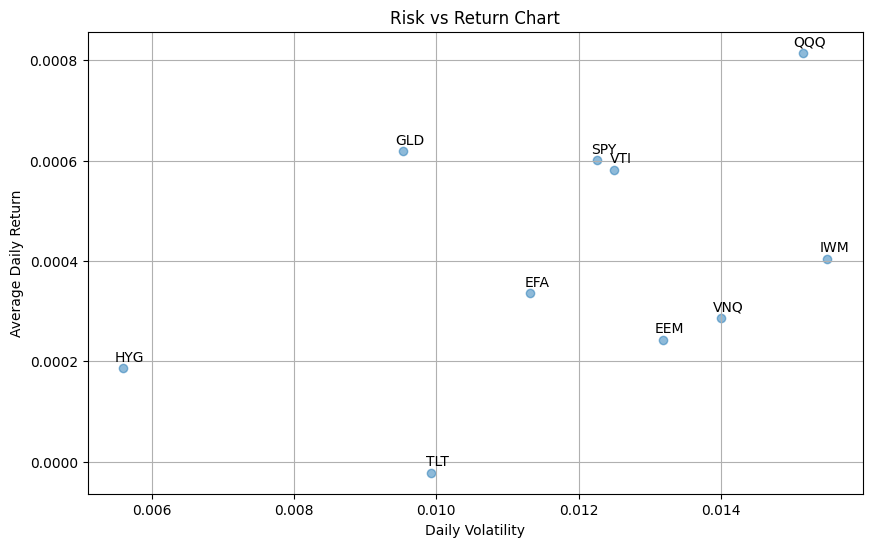

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(summary["Daily Volatility"], summary["Average Daily Return"], alpha=0.5)

for ticker in summary.index:
    plt.annotate(
        ticker,
         (summary.loc[ticker, "Daily Volatility"], summary.loc[ticker, "Average Daily Return"]
          ),
          textcoords="offset points",
          xytext=(5, 5),
          ha="center"
    )
plt.xlabel("Daily Volatility")
plt.ylabel("Average Daily Return")
plt.title("Risk vs Return Chart")
plt.grid(True)
plt.show()

Which ETF offered the best balance between average daily return and daily volatility (risk)? Based on the scatter plot, QQQ produced the highest average daily return with highest levels of daily volatility. GLD is one of the best balances presenting lower volatility and relatively high dailty average return. SPY and VTI offered similar risk-return profiles, but slightly less volatility than QQQ.


Cumulative Returns Chart

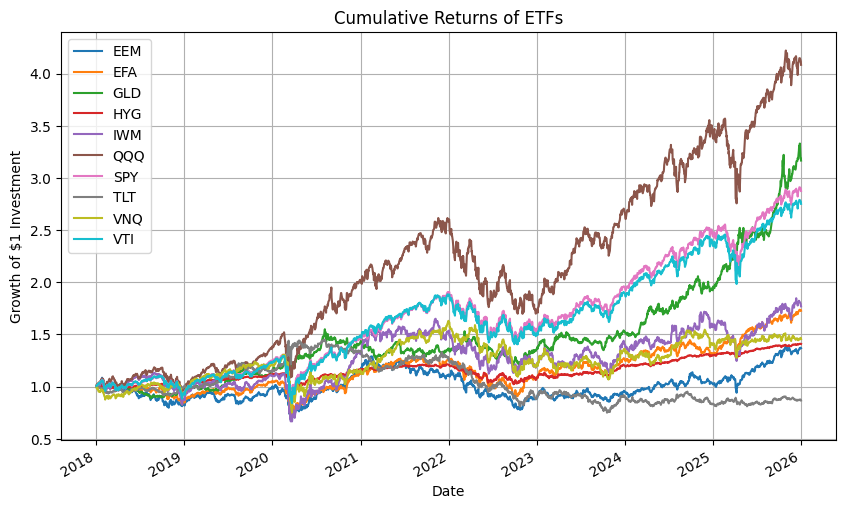

In [34]:
cumulative_returns.plot(figsize=(10, 6))
plt.title("Cumulative Returns of ETFs")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

How did Each ETF perform over time? QQQ achieved the strongest cumulative growth over the period, outperforming other ETFs. VTI and SPY experienced similar long-term growth, GLD showed solid performance. TLT, EFA, EEM generated comparatively lower comulative returns over the period.


Phase 4 - 4.1 Preparation for Portfolio Optimization

In [35]:
# Approximnate number of trading days in one year
trading_days = 252
# Expected annual returns
expected_annual_return = average_daily_returns * trading_days
# Annual covariance matrix
annual_covariance_matrix = returns.cov() * trading_days
# Annualized volatility
annualized_volatility = daily_volatility * np.sqrt(trading_days)

In [36]:
optimization_inputs = pd.DataFrame({
    "Average Daily Return": average_daily_returns,
    "Expected Annual Return": expected_annual_return,
    "Annualized Volatility": annualized_volatility,
})
optimization_inputs.style.format({
    "Average Daily Return": "{:.4%}",
    "Expected Annual Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}"
})

,Average Daily Return,Expected Annual Return,Annualized Volatility
Ticker,,,
EEM,0.0243%,6.13%,20.92%
EFA,0.0336%,8.48%,17.97%
GLD,0.0619%,15.60%,15.14%
HYG,0.0186%,4.69%,8.88%
IWM,0.0405%,10.20%,24.60%
QQQ,0.0815%,20.54%,24.05%
SPY,0.0601%,15.14%,19.46%
TLT,-0.0022%,-0.56%,15.75%
VNQ,0.0286%,7.20%,22.23%


In [37]:
annual_covariance_matrix

Ticker,EEM,EFA,GLD,HYG,IWM,QQQ,SPY,TLT,VNQ,VTI
Ticker,,,,,,,,,,
EEM,0.043784,0.031296,0.007024,0.012007,0.036353,0.036949,0.030904,-0.003818,0.026394,0.031848
EFA,0.031296,0.032282,0.005847,0.011970,0.035648,0.032949,0.029954,-0.003180,0.028000,0.030735
GLD,0.007024,0.005847,0.022908,0.002530,0.003694,0.003764,0.002820,0.005991,0.004974,0.002975
HYG,0.012007,0.011970,0.002530,0.007881,0.016174,0.014899,0.013511,0.001054,0.014449,0.013931
IWM,0.036353,0.035648,0.003694,0.016174,0.060528,0.045584,0.041544,-0.004752,0.040934,0.043846
QQQ,0.036949,0.032949,0.003764,0.014899,0.045584,0.057846,0.043880,-0.003854,0.032073,0.044493
SPY,0.030904,0.029954,0.002820,0.013511,0.041544,0.043880,0.037867,-0.004628,0.032256,0.038456
TLT,-0.003818,-0.003180,0.005991,0.001054,-0.004752,-0.003854,-0.004628,0.024807,0.000622,-0.004540
VNQ,0.026394,0.028000,0.004974,0.014449,0.040934,0.032073,0.032256,0.000622,0.049421,0.033419


Phase 4 - 4.2 Monte Carlo Portfolio Simulation
*   The objective is to evaluate thousands of possible portfolio allocations using historical expected returns and the annual covariance matrix. Each simulated portfolio will be assigned random weights that sum to 100%. For every portfolio, the expected return, annualized volatility, and Sharpe Ratio will be calculatd. The portfolio with the highest Sharpe Ratio will identified as the optimal risk-adjusted portfolio.




In [38]:
# Number of simulated portfolios
num_portfolios = 10000

# Number of ETFs
num_assets = len(expected_annual_return)

# Risk-free rate (example)
risk_free_rate = 0.04

In [39]:
portfolio_returns = np.zeros((num_portfolios))
portfolio_volatility = np.zeros((num_portfolios))
portfolio_sharpe_ratio = np.zeros((num_portfolios))
portfolio_weights = []

In [40]:
for i in range(num_portfolios):
    # Generate random portfolio weights
    weights = np.random.random(num_assets)
    # Normalize weights so they sum up to 1
    weights /= np.sum(weights)
    # Save portfolio weights
    portfolio_weights.append(weights)
    # Calculate expected return portfolio
    portfolio_returns[i] = np.dot(expected_annual_return, weights)
    # Calculate annualized porfolio volatility
    portfolio_volatility[i] = np.sqrt(np.dot(weights.T, np.dot(annual_covariance_matrix, weights)))
    # Calculate Sharpe Ratio
    portfolio_sharpe_ratio[i] = (portfolio_returns[i] - risk_free_rate) / portfolio_volatility[i]

In [41]:
print("Portfolios simulated:", len (portfolio_returns))
print("Weights stored:", len (portfolio_weights))
print("First portfolio weights sum:", portfolio_weights[0].sum())
print("First portfolio return:", portfolio_returns[0])
print("First portfolio volatility:", portfolio_volatility[0])
print("First portfolio Sharpe Ratio:", portfolio_sharpe_ratio[0])

Portfolios simulated: 10000
Weights stored: 10000
First portfolio weights sum: 0.9999999999999999
First portfolio return: 0.11043833623051619
First portfolio volatility: 0.12833254831729415
First portfolio Sharpe Ratio: 0.5488735099092853


4.3 Identify the Optimat Portfolio with Monte Carlo Simulation

In [42]:
max_sharpe_ratio_index = portfolio_sharpe_ratio.argmax()
max_sharpe_ratio_portfolio_return = portfolio_returns[max_sharpe_ratio_index]
max_sharpe_ratio_portfolio_volatility = portfolio_volatility[max_sharpe_ratio_index]
max_sharpe_ratio_portfolio_weights = portfolio_weights[max_sharpe_ratio_index]

In [43]:
print("Maximum Sharpe Ratio Portfolio")
print("------------------------------")
print(f"Portfolio Index:{max_sharpe_ratio_index}")
print(f"Expected Annual Return:{max_sharpe_ratio_portfolio_return: .2%}")
print(f"Annual Volatility:{max_sharpe_ratio_portfolio_volatility: .2%}")
print(f"Sharpe Ratio:{portfolio_sharpe_ratio[max_sharpe_ratio_index]:.3f}")

Maximum Sharpe Ratio Portfolio
------------------------------
Portfolio Index:1159
Expected Annual Return: 13.51%
Annual Volatility: 11.08%
Sharpe Ratio:0.858


In [44]:
optimal_portfolio = pd.DataFrame({
    "ETF": expected_annual_return.index,
    "Weight": max_sharpe_ratio_portfolio_weights
})
optimal_portfolio.style.format({
    "Weight": "{:.2%}"
})
# Convert to percentage
optimal_portfolio["Weight"] = optimal_portfolio["Weight"] * 100

# Sort from largest to smallest allocation
optimal_portfolio = optimal_portfolio.sort_values(by="Weight", ascending=True)

# Display
optimal_portfolio.style.format({
    "Weight": "{:.2f}%"
})

,ETF,Weight
4,IWM,0.24%
9,TLT,1.51%
6,VNQ,1.80%
5,EFA,2.89%
8,HYG,4.45%
3,VTI,11.76%
1,GLD,16.90%
7,EEM,17.76%
0,QQQ,18.42%
2,SPY,24.27%


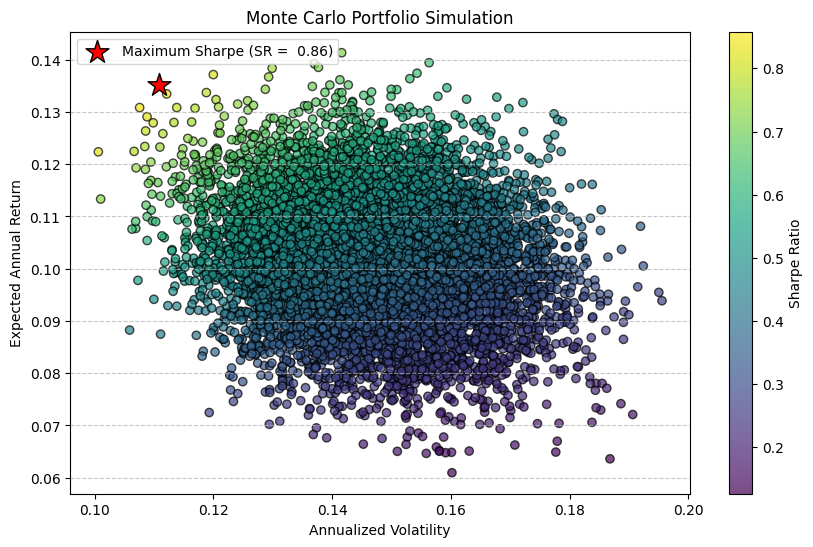

In [45]:
# Efficient Frontier Scatter Plot

plt.figure(figsize=(10, 6))

# Plot all simulted portfolios
scatter = plt.scatter(
    portfolio_volatility,
    portfolio_returns,
    c=portfolio_sharpe_ratio,
    cmap="viridis",
    edgecolors="k",
    alpha=0.7
)

# Highlight the maximum Sharpe Ratio portfolio
plt.scatter(
    max_sharpe_ratio_portfolio_volatility,
    max_sharpe_ratio_portfolio_return,
    c="red",
    edgecolors="k",
    marker="*",
    s=300,
    label = f"Maximum Sharpe (SR = {portfolio_sharpe_ratio[max_sharpe_ratio_index]: .2f})"
)
plt.title("Monte Carlo Portfolio Simulation")
plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend(loc="best")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

4.5 Mathematical Portfolio Optimization

In [46]:
from scipy.optimize import minimize

# Starting portfolio: equal weights
intial_weights = np.array(num_assets * [1 / num_assets])

# Constraint: portfolio weights must sum to 1
constraints = {
    "type": "eq",
    "fun": lambda x: np.sum(x) - 1
}

#Bounds: each ETF weight must be between 0% and 100%
bounds = tuple((0, 1) for _ in range(num_assets))

In [47]:
# Define portfolio calculations
def portfolio_performance(weights):
    # Calculate expected return portfolio
    portfolio_return = np.sum(expected_annual_return * weights)
    # Calculate expected risk portfolio
    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(annual_covariance_matrix, weights)
            )
        )
    # Calculate Sharpe Ratio
    portfolio_sharpe_ratio = (
        portfolio_return - risk_free_rate
        ) / portfolio_volatility

    return portfolio_return, portfolio_volatility, portfolio_sharpe_ratio

In [48]:
# Define the objective function
def negative_sharpe_ratio(weights):
    portfolio_return, portfolio_volatility, portfolio_sharpe_ratio = portfolio_performance(weights)
    return -portfolio_sharpe_ratio

In [49]:
# Run the optimizer
optimization_result = minimize(
    negative_sharpe_ratio,
    intial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

# Extract the optimized weights and performance
optimized_weights = optimization_result.x
optimized_return, optimized_volatility, optimized_sharpe_ratio = (
    portfolio_performance(optimized_weights)
)

In [50]:
#Mathematical optimization allocation table
optimized_portfolio = pd.DataFrame({
    "ETF": expected_annual_return.index,
    "Optimized Weight": optimized_weights
})
optimized_portfolio = optimized_portfolio.sort_values(
    by="Optimized Weight",
    ascending=False
)
optimized_portfolio.style.format({
    "Optimized Weight": "{:.2%}"
})

,ETF,Optimized Weight
3,VTI,78.04%
2,SPY,21.96%
9,TLT,0.00%
5,EFA,0.00%
4,IWM,0.00%
8,HYG,0.00%
6,VNQ,0.00%
0,QQQ,0.00%
7,EEM,0.00%
1,GLD,0.00%


Findings from the Mathematical Optimization allocation: the unconstrained math optimizer produced a highly concentrated allocation, assigning 78% to VTI and 22% to SPY. Although this allocation maximized the historical Sharpe Ratio, the concentration in two highly overlapping U.S. equity ETFs limits diversification and may make the result less practical for an investor.

4.6 Mathematical Optimizer with a maximum weight of 30%

In [51]:
#Limit each ETF to a maximum weight of 30%
practical_bounds = tuple((0, 0.3) for _ in range(num_assets))

# Run the optimizer
practical_optimization_result = minimize(
    negative_sharpe_ratio,
    intial_weights,
    method="SLSQP",
    bounds=practical_bounds,
    constraints=constraints
)

practical_optimized_weights = practical_optimization_result.x

(
    practical_optimized_return,
    practical_optimized_volatility,
    practical_optimized_sharpe_ratio
) = portfolio_performance(practical_optimized_weights)



In [52]:
print("Practical Constrained Portfolio")
print("------------------------------")
print("Optimization Successful", practical_optimization_result.success)
print("Message", practical_optimization_result.message)
print(f"Expected Annual Return:{practical_optimized_return: .2%}")
print(f"Annual Volatility:{practical_optimized_volatility:.2%}")
print(f"Sharpe Ratio:{practical_optimized_sharpe_ratio: .3f}")
print(f"Weights Sum:{practical_optimized_weights.sum():.6f}")
print(f"Maximum Weight:{practical_optimized_weights.max():.2%}")

Practical Constrained Portfolio
------------------------------
Optimization Successful True
Message Optimization terminated successfully
Expected Annual Return: 15.36%
Annual Volatility:10.17%
Sharpe Ratio: 1.118
Weights Sum:1.000000
Maximum Weight:30.00%


In [53]:
# Practical optimization allocation table
practical_optimized_portfolio = pd.DataFrame({
    "ETF": expected_annual_return.index,
    "Optimized Weight": practical_optimized_weights
})
practical_optimized_portfolio = practical_optimized_portfolio.sort_values(
    by="Optimized Weight",
    ascending=False
)
practical_optimized_portfolio.style.format({
    "Optimized Weight": "{:.2%}"
})

,ETF,Optimized Weight
2,SPY,30.00%
3,VTI,30.00%
0,QQQ,27.52%
7,EEM,12.48%
9,TLT,0.00%
1,GLD,0.00%
5,EFA,0.00%
4,IWM,0.00%
8,HYG,0.00%
6,VNQ,0.00%


The 30% maximum-weight constraint produced a more diversified allocation than the unconstrained model, doubling the porfolio from two ETFs to four. However, the allocaton remains concentrated in U.S. equities because VTI, SPY, and QQQ collectively account for approximately 87.5% of the portfolio. This demonstrates the weight limits can reduce concentration, but they do not eliminate overlap among similar assets.

4.7 Monte Carlo versus Mathematical Optimizer versus Practical Optimizer

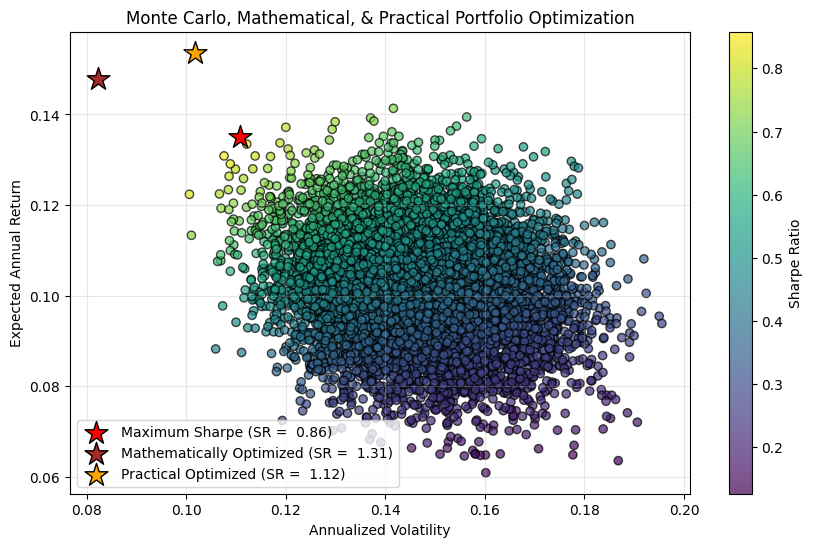

In [54]:
# Efficient Frontier Scatter Plot

plt.figure(figsize=(10, 6))

# Plot all Monte Carlo portfolios
scatter = plt.scatter(
    portfolio_volatility,
    portfolio_returns,
    c=portfolio_sharpe_ratio,
    cmap="viridis",
    edgecolors="k",
    alpha=0.7
)

# Highlight the Monte Carlo maximum Sharpe Ratio portfolio
plt.scatter(
    max_sharpe_ratio_portfolio_volatility,
    max_sharpe_ratio_portfolio_return,
    c="red",
    edgecolors="k",
    marker="*",
    s=300,
    label = f"Maximum Sharpe (SR = {portfolio_sharpe_ratio[max_sharpe_ratio_index]: .2f})"
)

# Highlight mathematically optimized portfolio
plt.scatter(
    optimized_volatility,
    optimized_return,
    marker="*",
    edgecolors="k",
    color="brown",
    s=300,
    label= f"Mathematically Optimized (SR = {optimized_sharpe_ratio: .2f})")

# Highlight mathematically optimized portfolio
plt.scatter(
    practical_optimized_volatility,
    practical_optimized_return,
    marker="*",
    edgecolors="k",
    color="orange",
    s=300,
    label= f"Practical Optimized (SR = {practical_optimized_sharpe_ratio: .2f})"
)

plt.title("Monte Carlo, Mathematical, & Practical Portfolio Optimization")
plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annual Return")

plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

4.8 Comparison of Portfolio Optimization Methods

In [55]:
#Combies allocation comparison table
comparison_results = pd.DataFrame({
    "Method": [
        "Monte Carlo",
        "Mathematical Optimization",
        "Practical Optimization (30% Cap)"
    ],
    "Expected Annual Return": [
        max_sharpe_ratio_portfolio_return,
        optimized_return,
        practical_optimized_return
    ],
    "Annual Volatility": [
        max_sharpe_ratio_portfolio_volatility,
        optimized_volatility,
        practical_optimized_volatility
    ],
      "Sharpe Ratio": [
        portfolio_sharpe_ratio[max_sharpe_ratio_index],
        optimized_sharpe_ratio,
        practical_optimized_sharpe_ratio
        ]
})

comparison_results.style.format({
    "Expected Annual Return": "{:.2%}",
    "Annual Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}"
})

,Method,Expected Annual Return,Annual Volatility,Sharpe Ratio
0,Monte Carlo,13.51%,11.08%,0.86
1,Mathematical Optimization,14.77%,8.23%,1.31
2,Practical Optimization (30% Cap),15.36%,10.17%,1.12


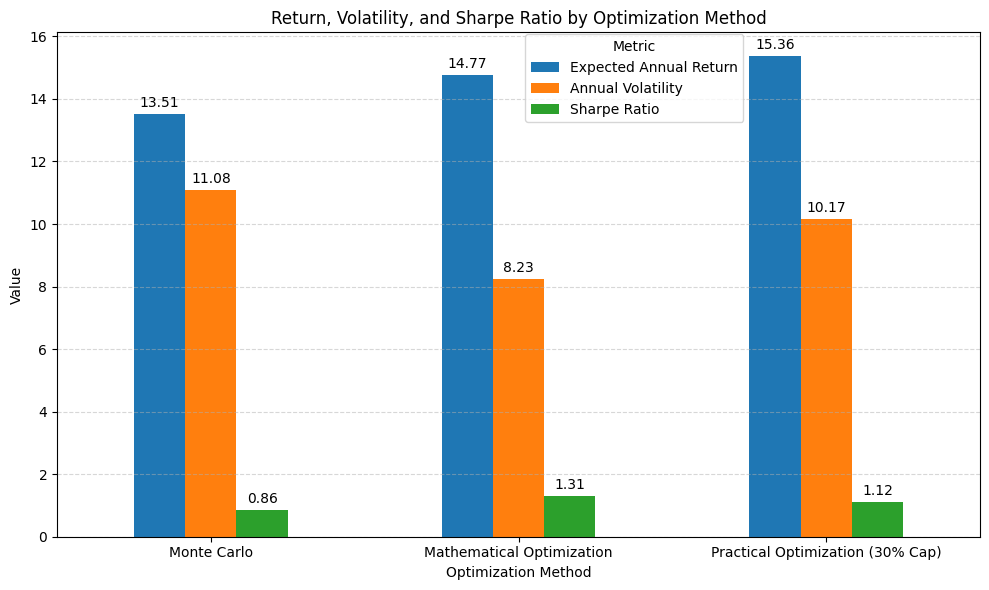

In [56]:
# Comparison bar chart
comparison_chart = comparison_results.set_index("Method").copy()

# Convert return and volatility to percentage points
comparison_chart["Expected Annual Return"] *= 100
comparison_chart["Annual Volatility"] *= 100

# Keep Sharpe Ratio on its natural scale
ax = comparison_chart.plot(
    kind="bar",
    figsize=(10,6)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt ="%.2f",
        padding=3
  )

plt.ylabel("Value")
plt.xlabel("Optimization Method")
plt.title("Return, Volatility, and Sharpe Ratio by Optimization Method")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Metric",
           loc="upper left",
           bbox_to_anchor=(0.5, 1.01))
plt.tight_layout()
plt.show()

In [57]:
#Allocation comparison table
allocation_comparison = pd.DataFrame({
    "ETF": expected_annual_return.index,
        "Monte Carlo": max_sharpe_ratio_portfolio_weights,
        "Mathematical Optimization": optimized_weights,
        "Practical Optimization (30% Cap)": practical_optimized_weights
})
allocation_comparison.style.format({
    "Monte Carlo": "{:.2%}",
    "Mathematical Optimization": "{:.2%}",
    "Practical Optimization (30% Cap)": "{:.2%}"
})

,ETF,Monte Carlo,Mathematical Optimization,Practical Optimization (30% Cap)
0,QQQ,18.42%,0.00%,27.52%
1,GLD,16.90%,0.00%,0.00%
2,SPY,24.27%,21.96%,30.00%
3,VTI,11.76%,78.04%,30.00%
4,IWM,0.24%,0.00%,0.00%
5,EFA,2.89%,0.00%,0.00%
6,VNQ,1.80%,0.00%,0.00%
7,EEM,17.76%,0.00%,12.48%
8,HYG,4.45%,0.00%,0.00%
9,TLT,1.51%,0.00%,0.00%


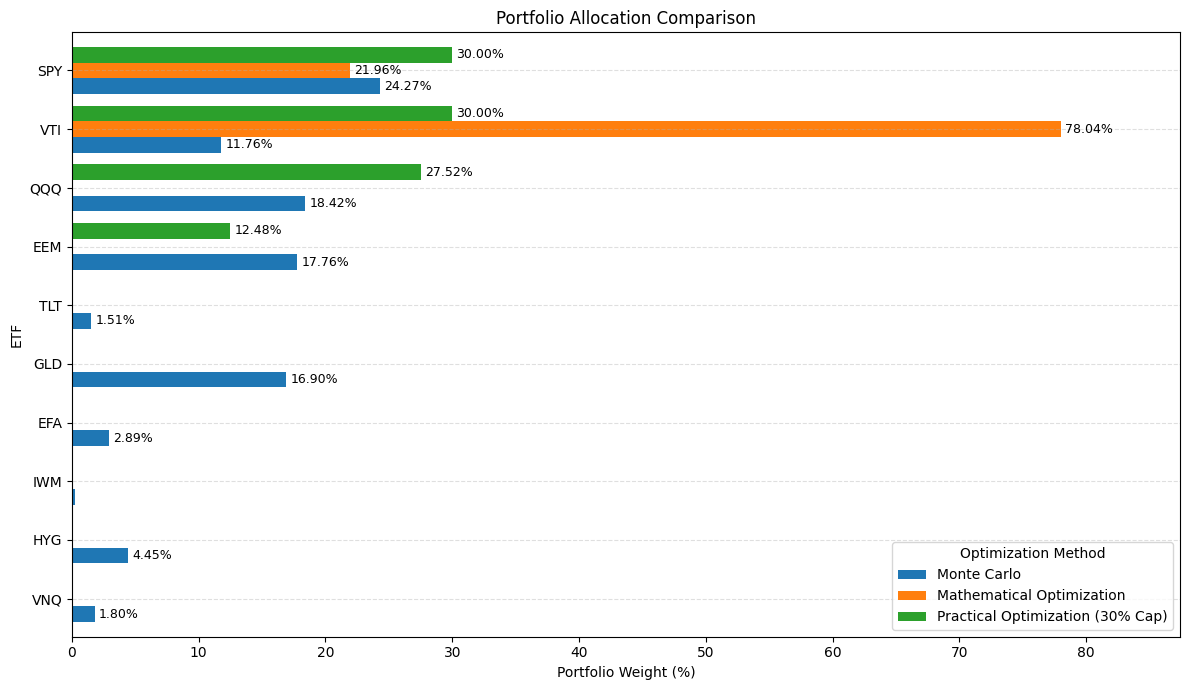

In [58]:
#Plotting the allocation comparison by security
allocation_chart = allocation_comparison.set_index("ETF")*100

allocation_chart = allocation_chart[
    allocation_chart.sum(axis=1) > 0.01
].sort_values(by="Practical Optimization (30% Cap)", ascending=True)

ax = allocation_chart.plot(
    kind="barh",
    figsize=(12,7),
    width=.8
)

for container in ax.containers:
    labels = [
    f"{bar.get_width():.2f}%"
    if bar.get_width() >= 0.5
    else ""
    for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.ylabel("ETF")
plt.xlabel("Portfolio Weight (%)")
plt.title("Portfolio Allocation Comparison")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Optimization Method",
           loc="lower right",
)
plt.xlim(
    0,
    allocation_chart.to_numpy().max()*1.12
)
plt.tight_layout()
plt.show()

# 4.9 Key Findings and Recommendations

The mathematical optimizer achieved the highest Sharpe Ratio but concentrated the portfolio in two overlapping U.S. equity ETFs. Applying a 30% maximum-weight constraint produced a more practical four-ETF allocation with stronger diversification while maintaining competitive return and risk-adjusted performmance. Therefore, the constrained portfolio was selected as the preferred recommendation, although the results remain depedent on historical market performance.

4.10 Conclusion

The analysis compared Monte Carlo simulation, mathematical optimization, and a practical constrained optimizaton approach to identify and ETF portfolio with strong risk-adjusted performance. While the unconstrained mathematical optimizer achieved the highest Sharpe Ratio, the 30% constrained portfolio provided greater diversification while maintaining competitive performance, making it the preferred recommendation.

4.11 Limitations



*   Results are based on historical market data and may not predict future performance.
*   The analysis does not account for transaction costs, taxes, or changing market conditions.
*   ETF overlap and other real-world investment considerations may affect portfolio performance.
